# Baseline Model

Train and evaluate baseline linear regression model.

Loading data from ..\data\processed\feature_engineered_data.csv

Metrics:
- train_r2: 0.9848
- test_r2: 0.9849
- train_rmse: 2628.8353
- test_rmse: 2631.5304
- train_mae: 1915.9739
- test_mae: 1955.9531

Top coefficients:


,feature,coefficient,abs_coefficient
0,Net_Price,171.281302,171.281302
1,Promotion_Score_rolling_mean_4,-77.805034,77.805034
2,Promotion_Score,50.179440,50.179440
3,Sales_Units,45.194802,45.194802
4,Promotion_Score_rolling_mean_12,-29.489412,29.489412
5,CPI,27.501969,27.501969
6,MRP,26.114946,26.114946
7,Promotion_Score_lag_2,25.002848,25.002848
8,Promotion_Score_lag_1,23.326065,23.326065
9,Promotion_Score_rolling_std_4,16.259821,16.259821



Feature importance plot saved to: ..\models\baseline\feature_importance.png


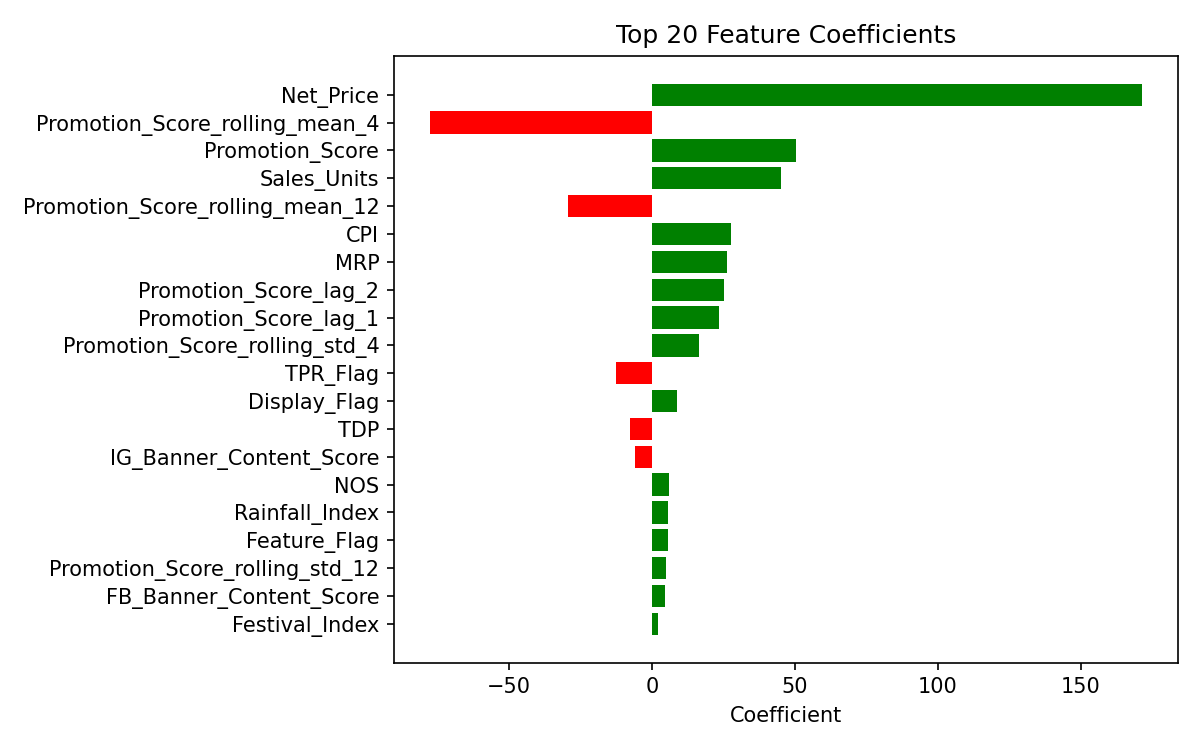


Business interpretation:
Baseline Linear Regression — Business Interpretation

Model performance:
- train_r2: 0.9848
- test_r2: 0.9849
- train_rmse: 2628.8353
- test_rmse: 2631.5304
- train_mae: 1915.9739
- test_mae: 1955.9531

Top positive drivers:
- Net_Price: coef=171.2813 (30.62% of total impact)
- Promotion_Score: coef=50.1794 (8.97% of total impact)
- Sales_Units: coef=45.1948 (8.08% of total impact)
- CPI: coef=27.5020 (4.92% of total impact)
- MRP: coef=26.1149 (4.67% of total impact)

Top negative drivers:
- Promotion_Score_rolling_mean_4: coef=-77.8050 (13.91% of total impact)
- Promotion_Score_rolling_mean_12: coef=-29.4894 (5.27% of total impact)
- TPR_Flag: coef=-12.7480 (2.28% of total impact)
- TDP: coef=-7.8602 (1.41% of total impact)
- IG_Banner_Content_Score: coef=-5.9497 (1.06% of total impact)

Notes: Coefficients are from an unconstrained linear model and represent short-term linear associations. Interpret with caution; run causal or experimental analysis for caus

In [2]:
from pathlib import Path
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image

sys.path.append('../src')
from feature_engineering import prepare_feature_importance_data

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Paths
input_path = Path('../data/processed/feature_engineered_data.csv')
output_dir = Path('../models/baseline')
output_dir.mkdir(parents=True, exist_ok=True)

# Load data
print(f'Loading data from {input_path}')
df = pd.read_csv(input_path)

# Prepare numeric features and target
id_columns = ['Week', 'Geo', 'Brand', 'SKU']
prepared_df, feature_columns = prepare_feature_importance_data(df, target_col='Sales_Value', id_columns=id_columns)
X = prepared_df[feature_columns].fillna(0)
y = prepared_df['Sales_Value'].astype(float).fillna(0)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit linear regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Metrics
metrics = {
    'train_r2': float(r2_score(y_train, y_pred_train)),
    'test_r2': float(r2_score(y_test, y_pred_test)),
    'train_rmse': float(np.sqrt(mean_squared_error(y_train, y_pred_train))),
    'test_rmse': float(np.sqrt(mean_squared_error(y_test, y_pred_test))),
    'train_mae': float(mean_absolute_error(y_train, y_pred_train)),
    'test_mae': float(mean_absolute_error(y_test, y_pred_test))
}

print('\nMetrics:')
for k, v in metrics.items():
    print(f'- {k}: {v:.4f}')

# Coefficients DataFrame
coef = np.asarray(model.coef_).ravel()
coef_df = pd.DataFrame({'feature': feature_columns, 'coefficient': coef})
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coefficient', ascending=False).reset_index(drop=True)
coef_csv = output_dir / 'feature_coefficients.csv'
coef_df.to_csv(coef_csv, index=False)

print('\nTop coefficients:')
display(coef_df.head(20))

# Plot and save feature importance
plot_file = output_dir / 'feature_importance.png'
top = coef_df.head(20).iloc[::-1]
plt.figure(figsize=(8, max(4, len(top) * 0.25)))
colors = ['green' if v >= 0 else 'red' for v in top['coefficient']]
plt.barh(top['feature'], top['coefficient'], color=colors)
plt.xlabel('Coefficient')
plt.title(f'Top {len(top)} Feature Coefficients')
plt.tight_layout()
plt.savefig(plot_file, dpi=150)
plt.close()

print(f'\nFeature importance plot saved to: {plot_file}')
try:
    display(Image(str(plot_file)))
except Exception as e:
    print(f'Could not display plot: {e}')

# Business interpretation (simple automated summary)
coef_sum = coef_df['abs_coefficient'].sum() if coef_df['abs_coefficient'].sum() != 0 else 1.0
interp_lines = []
interp_lines.append('Baseline Linear Regression — Business Interpretation')
interp_lines.append('')
interp_lines.append('Model performance:')
for k, v in metrics.items():
    interp_lines.append(f'- {k}: {v:.4f}')
interp_lines.append('')
interp_lines.append('Top positive drivers:')
for _, r in coef_df[coef_df['coefficient'] > 0].head(5).iterrows():
    pct = 100.0 * r['abs_coefficient'] / coef_sum
    interp_lines.append(f"- {r['feature']}: coef={r['coefficient']:.4f} ({pct:.2f}% of total impact)")
interp_lines.append('')
interp_lines.append('Top negative drivers:')
for _, r in coef_df[coef_df['coefficient'] < 0].head(5).iterrows():
    pct = 100.0 * r['abs_coefficient'] / coef_sum
    interp_lines.append(f"- {r['feature']}: coef={r['coefficient']:.4f} ({pct:.2f}% of total impact)")
interp_lines.append('')
interp_lines.append('Notes: Coefficients are from an unconstrained linear model and represent short-term linear associations. Interpret with caution; run causal or experimental analysis for causal claims.')

interp_file = output_dir / 'business_interpretation.txt'
interp_file.write_text('\n'.join(interp_lines))

print('\nBusiness interpretation:')
print(interp_file.read_text())

# Save model and metrics
model_file = output_dir / 'linear_regression_model_notebook.pkl'
with open(model_file, 'wb') as f:
    import pickle
    pickle.dump(model, f)

metrics_file = output_dir / 'metrics_notebook.json'
pd.Series(metrics).to_json(metrics_file)

print(f"\nModel and artifacts saved to: {output_dir}")